# 粗分类

## 数据预处理

### 将数据按类别放入不同的文件夹

In [12]:
import cv2
import numpy as np
import keras
import tensorflow as tf
import pandas as pd
import os
import shutil
from tqdm import tqdm
import random
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
import skimage.io as io
from PIL import Image,ImageDraw, ImageFont
import time, csv
import seaborn as sns
import matplotlib.image as mpimg
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Model
from keras.layers import BatchNormalization, GlobalAveragePooling2D, Lambda, InputLayer, Input
from keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras import layers, models
from keras.applications.inception_v3 import InceptionV3, preprocess_input
from keras.callbacks import EarlyStopping
from keras.applications.xception import Xception, preprocess_input
from keras.applications.nasnet import NASNetLarge, preprocess_input
from sklearn.manifold import TSNE
from keras.applications.inception_resnet_v2 import InceptionResNetV2, preprocess_input

np.random.seed(42)
%matplotlib inline 

In [1]:
# 复制文件
def cp_file(src, dst):
    shutil.copyfile(src=src, dst=dst)

# 创建目录
def create_folders(path):
    if not os.path.exists(path):
        os.makedirs(path, exist_ok=True)

In [26]:
def split_datasets(label_path, image_dir, save_dir, mode='train', ratio=0.1):
    # 读取标签文件
    label_df = pd.read_csv(label_path)
    label_length = label_df.describe().iloc[0].id
    dogs = list(set(label_df.iloc[:, 1].to_list()))  
    dogs2ids = dict.fromkeys(dogs, [])
    cate_info = dict.fromkeys(dogs, 0)
    for dog in dogs:
        mode = 'train'
        nums = label_df.loc[label_df.iloc[:, 1]==dog].count()[0]
        cate_info[dog] = nums
        dogs2ids[dog].extend(list(label_df.loc[label_df.iloc[:, 1]==dogs[0]].id))
        dogs_list= list(label_df.loc[label_df.iloc[:, 1]==dog].id)
        random.shuffle(dogs_list)
        
        train_len = int(nums * (1-ratio))
        test_len = int(nums * ratio)
        for fn in tqdm(dogs_list[:train_len], desc=f'split 【{dog}】 train datesets'):
            fname = fn + '.JPG'
            cate_info[dog] += 1
            f_path = os.path.join(image_dir, fname)
            if not os.path.exists(f_path):
                continue
            dst_dir = os.path.join(save_dir, mode, dog)
            dst_path = os.path.join(save_dir, mode, dog, fname)
            create_folders(dst_dir)
            cp_file(f_path, dst_path)
        
        mode = 'val'
        for fn in tqdm(dogs_list[train_len:],desc=f'split test 【{dog}】datesets'):
            fname = fn + '.JPG'
            cate_info[dog] += 1
            f_path = os.path.join(image_dir, fname)
            if not os.path.exists(f_path):
                continue
            dst_dir = os.path.join(save_dir, mode, dog)
            dst_path = os.path.join(save_dir, mode, dog, fname)
            create_folders(dst_dir)
            cp_file(f_path, dst_path)

In [27]:
label_path = r'./labels.csv'
image_dir = r'./train'
save_dir = r'./dog_datasets'
split_datasets(label_path, image_dir=image_dir, save_dir=save_dir,mode='train')

C:\Users\Administrator\AppData\Local\Temp\ipykernel_17588\2068587300.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  nums = label_df.loc[label_df.iloc[:, 1]==cat].count()[0]
split test 【japanese_spaniel】datesets: 100%|████████████████████████████████████████| 11/11 [00:00<00:00, 499.67it/s]
C:\Users\Administrator\AppData\Local\Temp\ipykernel_17588\2068587300.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  nums = label_df.loc[label_df.iloc[:, 1]==cat].count()[0]
split test 【kelpie】datesets: 100%|████████████████████████████████████████████████████| 9/9 [00:00<00:00, 445.64it/s]
C:\Users\Administrator\AppData

split test 【dhole】datesets: 100%|█████████████████████████████████████████████████████| 8/8 [00:00<00:00, 381.98it/s]
C:\Users\Administrator\AppData\Local\Temp\ipykernel_17588\2068587300.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  nums = label_df.loc[label_df.iloc[:, 1]==cat].count()[0]
split test 【english_setter】datesets: 100%|████████████████████████████████████████████| 9/9 [00:00<00:00, 419.56it/s]
C:\Users\Administrator\AppData\Local\Temp\ipykernel_17588\2068587300.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  nums = label_df.loc[label_df.iloc[:, 1]==cat].count()[0]
split test 【english_springer】d

split test 【miniature_schnauzer】datesets: 100%|███████████████████████████████████████| 8/8 [00:00<00:00, 250.31it/s]
C:\Users\Administrator\AppData\Local\Temp\ipykernel_17588\2068587300.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  nums = label_df.loc[label_df.iloc[:, 1]==cat].count()[0]
split test 【appenzeller】datesets: 100%|███████████████████████████████████████████████| 8/8 [00:00<00:00, 363.25it/s]
C:\Users\Administrator\AppData\Local\Temp\ipykernel_17588\2068587300.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  nums = label_df.loc[label_df.iloc[:, 1]==cat].count()[0]
split test 【chesapeake_bay_ret

split test 【boxer】datesets: 100%|█████████████████████████████████████████████████████| 8/8 [00:00<00:00, 358.28it/s]
C:\Users\Administrator\AppData\Local\Temp\ipykernel_17588\2068587300.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  nums = label_df.loc[label_df.iloc[:, 1]==cat].count()[0]
split test 【blenheim_spaniel】datesets: 100%|████████████████████████████████████████| 11/11 [00:00<00:00, 378.76it/s]
C:\Users\Administrator\AppData\Local\Temp\ipykernel_17588\2068587300.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  nums = label_df.loc[label_df.iloc[:, 1]==cat].count()[0]
split test 【cairn】datesets: 10

split test 【toy_poodle】datesets: 100%|████████████████████████████████████████████████| 8/8 [00:00<00:00, 299.30it/s]
C:\Users\Administrator\AppData\Local\Temp\ipykernel_17588\2068587300.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  nums = label_df.loc[label_df.iloc[:, 1]==cat].count()[0]
split test 【ibizan_hound】datesets: 100%|████████████████████████████████████████████| 10/10 [00:00<00:00, 421.20it/s]
C:\Users\Administrator\AppData\Local\Temp\ipykernel_17588\2068587300.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  nums = label_df.loc[label_df.iloc[:, 1]==cat].count()[0]
split test 【dandie_dinmont】dat

split test 【afghan_hound】datesets: 100%|████████████████████████████████████████████| 12/12 [00:00<00:00, 338.44it/s]
C:\Users\Administrator\AppData\Local\Temp\ipykernel_17588\2068587300.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  nums = label_df.loc[label_df.iloc[:, 1]==cat].count()[0]
split test 【groenendael】datesets: 100%|███████████████████████████████████████████████| 9/9 [00:00<00:00, 179.30it/s]
C:\Users\Administrator\AppData\Local\Temp\ipykernel_17588\2068587300.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  nums = label_df.loc[label_df.iloc[:, 1]==cat].count()[0]
split test 【siberian_husky】dat

split test 【irish_water_spaniel】datesets: 100%|███████████████████████████████████████| 8/8 [00:00<00:00, 336.39it/s]
C:\Users\Administrator\AppData\Local\Temp\ipykernel_17588\2068587300.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  nums = label_df.loc[label_df.iloc[:, 1]==cat].count()[0]
split test 【border_terrier】datesets: 100%|██████████████████████████████████████████| 10/10 [00:00<00:00, 412.31it/s]
C:\Users\Administrator\AppData\Local\Temp\ipykernel_17588\2068587300.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  nums = label_df.loc[label_df.iloc[:, 1]==cat].count()[0]
split test 【pembroke】datesets:

split test 【french_bulldog】datesets: 100%|████████████████████████████████████████████| 7/7 [00:00<00:00, 350.05it/s]
C:\Users\Administrator\AppData\Local\Temp\ipykernel_17588\2068587300.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  nums = label_df.loc[label_df.iloc[:, 1]==cat].count()[0]
split test 【giant_schnauzer】datesets: 100%|███████████████████████████████████████████| 7/7 [00:00<00:00, 369.02it/s]
C:\Users\Administrator\AppData\Local\Temp\ipykernel_17588\2068587300.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  nums = label_df.loc[label_df.iloc[:, 1]==cat].count()[0]
split test 【schipperke】dateset

split test 【kerry_blue_terrier】datesets: 100%|████████████████████████████████████████| 9/9 [00:00<00:00, 399.72it/s]
C:\Users\Administrator\AppData\Local\Temp\ipykernel_17588\2068587300.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  nums = label_df.loc[label_df.iloc[:, 1]==cat].count()[0]
split test 【doberman】datesets: 100%|██████████████████████████████████████████████████| 8/8 [00:00<00:00, 445.62it/s]
C:\Users\Administrator\AppData\Local\Temp\ipykernel_17588\2068587300.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  nums = label_df.loc[label_df.iloc[:, 1]==cat].count()[0]
split test 【brittany_spaniel】d

## 读取并增强

In [13]:
# 设置数据集路径
data_dir = r"C:\Users\Administrator\Desktop\dog_2"
long_dir = os.path.join(data_dir, "long")
short_dir = os.path.join(data_dir, "short")


# 读取图像并进行增强
image_size = (224, 224)
batch_size = 128

In [14]:
# 使用ImageDataGenerator进行图像增强
datagen = ImageDataGenerator(
    featurewise_center=True, 
    featurewise_std_normalization=True,
    rescale=1.0 / 255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode='nearest',
    horizontal_flip=True,
    zoom_range=0.8
)

In [15]:
# 从文件夹加载图像并进行增强
train_dataset = datagen.flow_from_directory(
    data_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary'
)

Found 10297 images belonging to 2 classes.


## 模型

### VGG

In [9]:
pre_train_model=VGG16(input_shape=(224,224,3),
                            include_top=False,#设置不要最后的连接层
                            weights='imagenet'
                            )

In [10]:
#冻结层
for layer in pre_train_model.layers:
    layer.trainable=False#这里面的所有层的训练数据都不会更新，使用设定好的参数

In [11]:
# 构建模型
model = Sequential([
    pre_train_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 flatten (Flatten)           (None, 25088)             0         
                                                                 
 dense (Dense)               (None, 256)               6422784   
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 1)                 257       
                                                                 
Total params: 21137729 (80.63 MB)
Trainable params: 6423041 (24.50 MB)
Non-trainable params: 14714688 (56.13 MB)
_________________________________________________________________


In [12]:
# 编译模型
model.compile(optimizer=Adam(),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [13]:
# 训练模型
q=model.fit(train_dataset, epochs=20,validation_data=train_dataset,validation_steps=50)

C:\ProgramData\Anaconda3\envs\tensorflow\lib\site-packages\keras\src\preprocessing\image.py:1861: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(
C:\ProgramData\Anaconda3\envs\tensorflow\lib\site-packages\keras\src\preprocessing\image.py:1871: UserWarning: This ImageDataGenerator specifies `featurewise_std_normalization`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(


Epoch 1/20
81/81 [==============================] - 3369s 42s/step - loss: 0.9689 - accuracy: 0.5729 - val_loss: 0.6410 - val_accuracy: 0.6227
Epoch 2/20
81/81 [==============================] - 3314s 41s/step - loss: 0.6439 - accuracy: 0.6155 - val_loss: 0.6194 - val_accuracy: 0.6408
Epoch 3/20
81/81 [==============================] - 3645s 45s/step - loss: 0.6328 - accuracy: 0.6174 - val_loss: 0.6119 - val_accuracy: 0.6470
Epoch 4/20
81/81 [==============================] - 3623s 45s/step - loss: 0.6294 - accuracy: 0.6232 - val_loss: 0.5971 - val_accuracy: 0.6697
Epoch 5/20
81/81 [==============================] - 3433s 43s/step - loss: 0.6287 - accuracy: 0.6191 - val_loss: 0.5936 - val_accuracy: 0.6781
Epoch 6/20
81/81 [==============================] - 3295s 41s/step - loss: 0.6225 - accuracy: 0.6185 - val_loss: 0.6072 - val_accuracy: 0.6673
Epoch 7/20
81/81 [==============================] - 3292s 41s/step - loss: 0.6234 - accuracy: 0.6224 - val_loss: 0.6077 - val_accuracy: 0.6470

{'loss': [0.9688501358032227, 0.6438945531845093, 0.6327662467956543, 0.6293520927429199, 0.6286593675613403, 0.6225059032440186, 0.6234297156333923, 0.617868959903717, 0.6169992685317993, 0.6136854290962219, 0.6169394254684448, 0.6111993789672852, 0.6081941723823547, 0.6102892756462097, 0.6057003736495972, 0.6112831830978394, 0.6062132716178894, 0.6040996313095093, 0.6110105514526367, 0.6065773963928223], 'accuracy': [0.5728853344917297, 0.615519106388092, 0.6173642873764038, 0.623191237449646, 0.6191123723983765, 0.6185296773910522, 0.6224142909049988, 0.6320287585258484, 0.6248421669006348, 0.6242594718933105, 0.6332912445068359, 0.6342623829841614, 0.6356220245361328, 0.6361076235771179, 0.6341652870178223, 0.6349422335624695, 0.6367874145507812, 0.6357191205024719, 0.6239681243896484, 0.6274642944335938], 'val_loss': [0.6410108804702759, 0.6194055676460266, 0.6118967533111572, 0.5970860719680786, 0.5935583710670471, 0.6072452664375305, 0.6077187061309814, 0.5951164364814758, 0.619

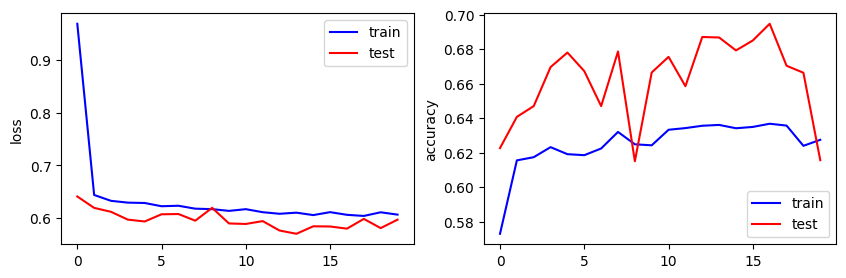

In [14]:
#可视化结果
print(q.history)
loss = q.history['loss']
acc = q.history['accuracy']
val_loss = q.history['val_loss']
val_acc = q.history['val_accuracy']

plt.figure(figsize=(10,3))

#绘制损失图
plt.subplot(121)
plt.plot(loss,color='b',label='train')
plt.plot(val_loss,color='r',label='test')
plt.ylabel('loss')
plt.legend()

#绘制准确率图
plt.subplot(122)
plt.plot(acc,color='b',label='train')
plt.plot(val_acc,color='r',label='test')
plt.ylabel('accuracy')
plt.legend()

## 模型测试

### 获取测试数据

In [15]:
# 设置数据集路径
data_dir = r"C:\Users\Administrator\Desktop\dog_2_test"
long_dir = os.path.join(data_dir, "long")
short_dir = os.path.join(data_dir, "short")


# 读取图像并进行增强
image_size = (224, 224)
batch_size = 128

In [16]:
# 使用ImageDataGenerator进行图像增强
datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

In [17]:
# 从文件夹加载图像并进行增强
test_dataset = datagen.flow_from_directory(
    data_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary'
)

Found 10297 images belonging to 2 classes.


In [18]:
y_pred = model.predict(test_dataset, batch_size=128)

81/81 [==============================] - 2102s 26s/step


### F1分数和混淆矩阵

In [19]:
# 生成测试集预测结果
y_true = test_dataset.classes

In [20]:
# 计算F1分数
f1 = f1_score(y_true, y_pred > 0.5)  
print("F1 score:", f1)

F1 score: 0.7230769230769231


### 预测展示

1/1 [==============================] - 0s 180ms/step
预测结果为long


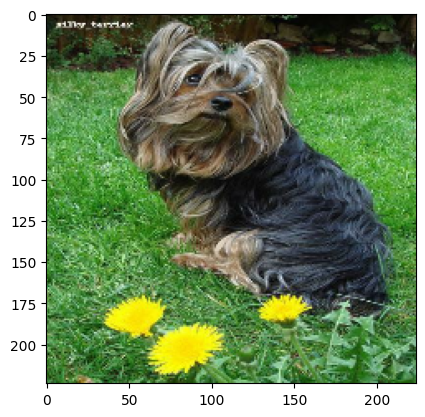

In [53]:
image_path = r"./dog_2_test/long/fdc0556f9b32a714b56985eb99fbbbeb.jpg" # 输入的图片路径


def preprocess_for_train(image_path):
    
  # 用tf读图，并做resize，以及归一化
    image_string = tf.io.read_file(image_path)
    image_decoded = tf.image.decode_jpeg(image_string)
    image_resized = tf.image.resize(image_decoded, [224, 224]) / 255.0
    image_resized = tf.expand_dims(image_resized, 0)
    return image_resized


image = preprocess_for_train(image_path)
pred = model.predict(image)
pred = np.argmax(pred)
label=['long','short']
y_pred = label[pred]
print("预测结果为{}".format(y_pred))
plt.imshow(image[0], cmap=plt.cm.binary)
plt.xlabel(image_path.split('.')[0])
plt.show()

1/1 [==============================] - 0s 167ms/step
预测结果为short


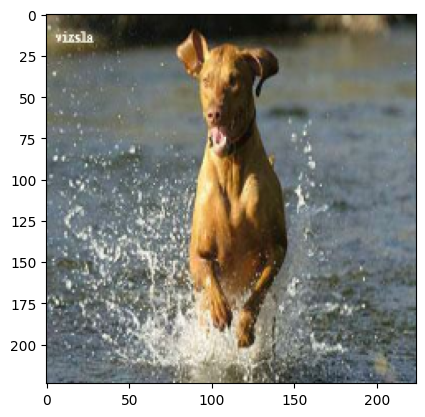

In [54]:
image_path = r"./dog_2_test/short/0b1e71a499a26eaacc06991bca982523.jpg" # 输入的图片路径


def preprocess_for_train(image_path):
    
  # 用tf读图，并做resize，以及归一化
    image_string = tf.io.read_file(image_path)
    image_decoded = tf.image.decode_jpeg(image_string)
    image_resized = tf.image.resize(image_decoded, [224, 224]) / 255.0
    image_resized = tf.expand_dims(image_resized, 0)
    return image_resized


image = preprocess_for_train(image_path)
pred = model.predict(image)
pred = np.argmax(pred)
y_pred = label[pred]
print("预测结果为{}".format(y_pred))
plt.imshow(image[0], cmap=plt.cm.binary)
plt.xlabel(image_path.split('.')[0])
plt.show()

# 细分类--长毛

## 数据读取

In [14]:
#读取种类标签
labels_dataframe = pd.read_csv("labels-long.csv")
# 列举所有种类，这里的set方法可以做集合，使同一个品种只出现一次。
breeds_map = list(set(labels_dataframe['breed']))
labels_dataframe

,id,breed
0,002a283a315af96eaea0e28e7163b21b,borzoi
1,01dffcb02d6cba7d2b101fcc93daa6f1,border_collie
2,02d54f0dfb40038765e838459ae8c956,bernese_mountain_dog
3,032c14b2df4193004913b01ab48f87c6,border_collie
4,0379145880ad3978f9b80f0dc2c03fba,afghan_hound
...,...,...
4127,ff52a3909f5801a71161cec95d213107,west_highland_white_terrier
4128,ff7d9c08091acc3b18b869951feeb013,maltese_dog
4129,ffa0055ec324829882186bae29491645,maltese_dog
4130,ffc532991d3cd7880d27a449ed1c4770,tibetan_terrier


In [16]:
# 读取图像数据
image_collection = io.imread_collection('dog_2/long/*.jpg')

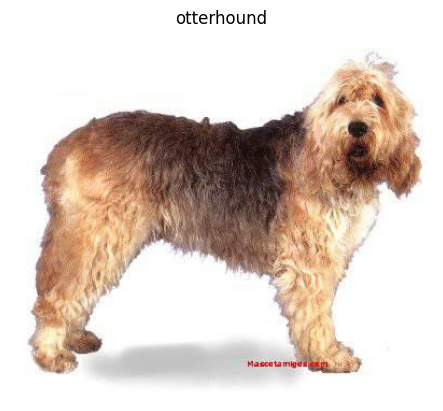

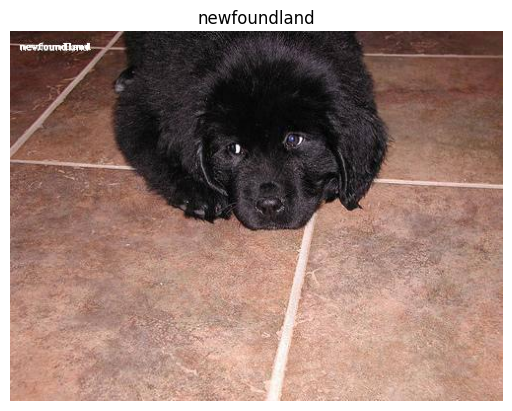

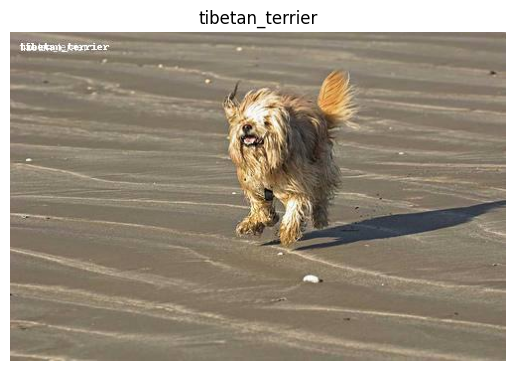

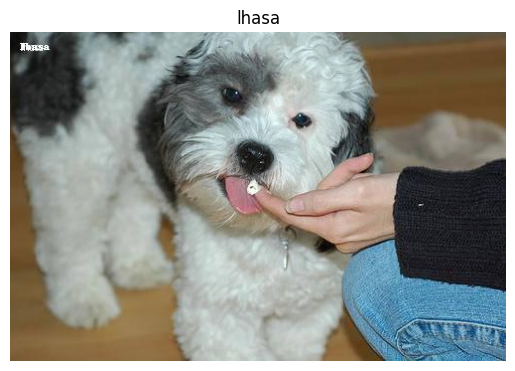

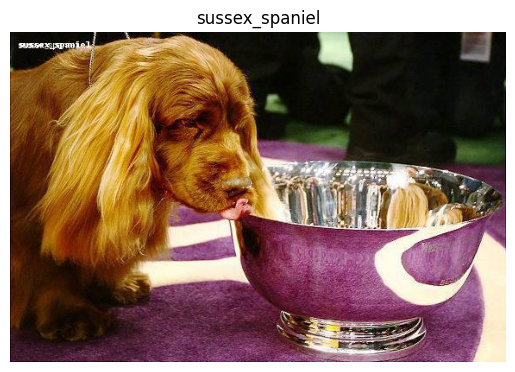

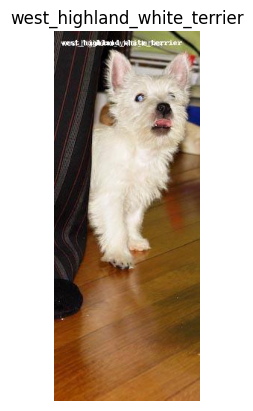

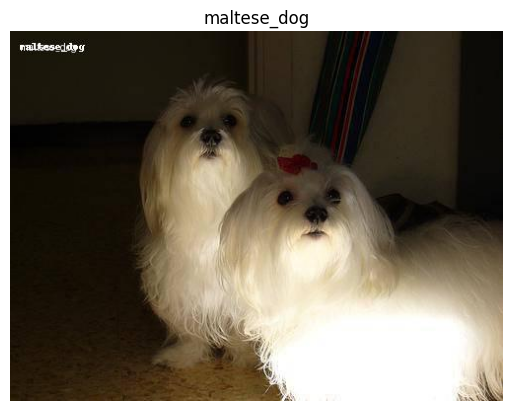

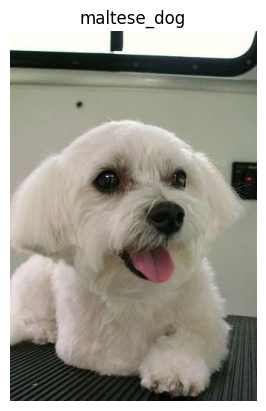

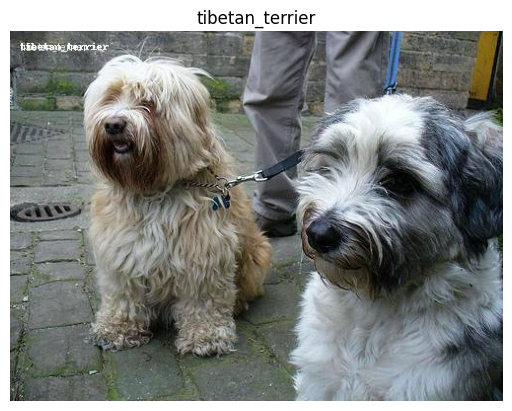

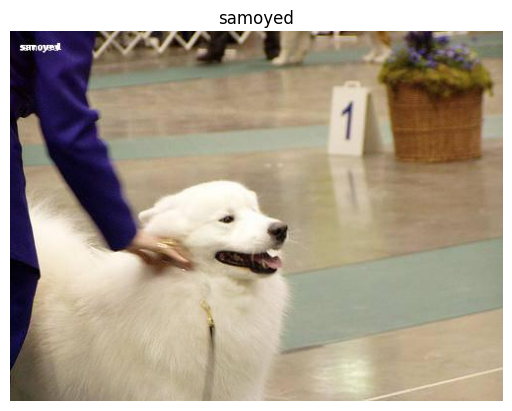

In [17]:
# 遍历10个图像，并读取对应标签
for index, row in labels_dataframe.tail(10).iterrows():
    image_id = row['id']
    breed = row['breed']

    # 构建图像路径
    image_path = os.path.join('train', f'{image_id}.jpg')

    # 打开图像
    image = Image.open(image_path)

    # 在图像上添加标签
    image_with_label = ImageDraw.Draw(image)
    image_with_label.text((10, 10), breed, fill=(255, 255, 255))

    # 显示图像
    plt.imshow(image)
    plt.title(breed)
    plt.axis('off')
    plt.show()

## 数据预处理

In [22]:
#创建函数以获取文件数量确定大小
def get_num_files(path):
    if not os.path.exists(path):
        return 0
    return sum([len(files) for r, d, files in os.walk(path)])

In [23]:
train_dir = 'dog_2/long'
test_dir = 'dog_2_test/long'

data_size = get_num_files(train_dir)
test_size = get_num_files(test_dir)
print('Data samples size: ', data_size)
print('Test samples size: ', test_size)

Data samples size:  4214
Test samples size:  4214


In [24]:
#创建标签列表并按字母排序
dog_breeds = sorted(list(set(labels_dataframe['breed'])))
n_classes = len(dog_breeds)
print(n_classes)
dog_breeds[:10]

48


['afghan_hound',
 'bernese_mountain_dog',
 'blenheim_spaniel',
 'border_collie',
 'borzoi',
 'briard',
 'brittany_spaniel',
 'cardigan',
 'collie',
 'curly-coated_retriever']

In [25]:
class_to_num = dict(zip(dog_breeds, range(n_classes)))

In [26]:
'''
创建函数：1.从文件夹中读取图像样本
2.将它们堆成一个数组
3.读取样本标签
4.将标签变成独热编码
5.打乱数据
'''
def images_to_array(data_dir, labels_dataframe, img_size = (224,224,3)):
    images_names = labels_dataframe['id']
    images_labels = labels_dataframe['breed']
    data_size = len(images_names)

    X = np.zeros([data_size, img_size[0], img_size[1], img_size[2]], dtype=np.uint8)
    y = np.zeros([data_size,1], dtype=np.uint8)
    #读数据和标签
    for i in tqdm(range(data_size)):
        image_name = images_names[i]
        img_dir = os.path.join(data_dir, image_name+'.jpg')
        img_pixels = load_img(img_dir, target_size=img_size)
        X[i] = img_pixels
        
        image_breed = images_labels[i]
        y[i] = class_to_num[image_breed]
    
    #独热
    y = to_categorical(y)
    #打乱   
    ind = np.random.permutation(data_size)
    X = X[ind]
    y = y[ind]
    print('Ouptut Data Size: ', X.shape)
    print('Ouptut Label Size: ', y.shape)
    return X, y

In [27]:
img_size = (331,331,3)
X, y = images_to_array(train_dir, labels_dataframe, img_size)

100%|█████████████████████████████████████████████████████████████████████████████| 4132/4132 [00:09<00:00, 420.86it/s]


Ouptut Data Size:  (4132, 331, 331, 3)
Ouptut Label Size:  (4132, 48)


# 原图像训练DNN

In [ ]:
# 定义DNN模型
def create_dnn_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Flatten(input_shape=input_shape),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# 创建模型实例
input_shape = (331, 331, 3)
num_classes = 48
dnn = create_dnn_model(input_shape, num_classes)
dnn.summary()

In [ ]:
# 编译模型
dnn.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

In [ ]:
#训练模型
t = dnn.fit(X, y,
            batch_size=128,
            epochs=30,
            validation_split=0.1)

# 特征提取

In [20]:
#创建一个函数用来创建特征提取器并返回
def get_features(model_name, data_preprocessor, input_size, data):
    #准备管道
    input_layer = Input(input_size)
    preprocessor = Lambda(data_preprocessor)(input_layer)
    base_model = model_name(weights='imagenet', include_top=False,
                            input_shape=input_size)(preprocessor)
    avg = GlobalAveragePooling2D()(base_model)
    feature_extractor = Model(inputs = input_layer, outputs = avg)
    #提取特征
    feature_maps = feature_extractor.predict(data, batch_size=64, verbose=1)
    print('Feature maps shape: ', feature_maps.shape)
    return feature_maps

In [29]:
#使用InceptionV3作为提取器提取特征。
inception_preprocessor = preprocess_input
inception_features = get_features(InceptionV3,inception_preprocessor,img_size, X)

65/65 [==============================] - 572s 9s/step
Feature maps shape:  (4132, 2048)


# 特征可视化

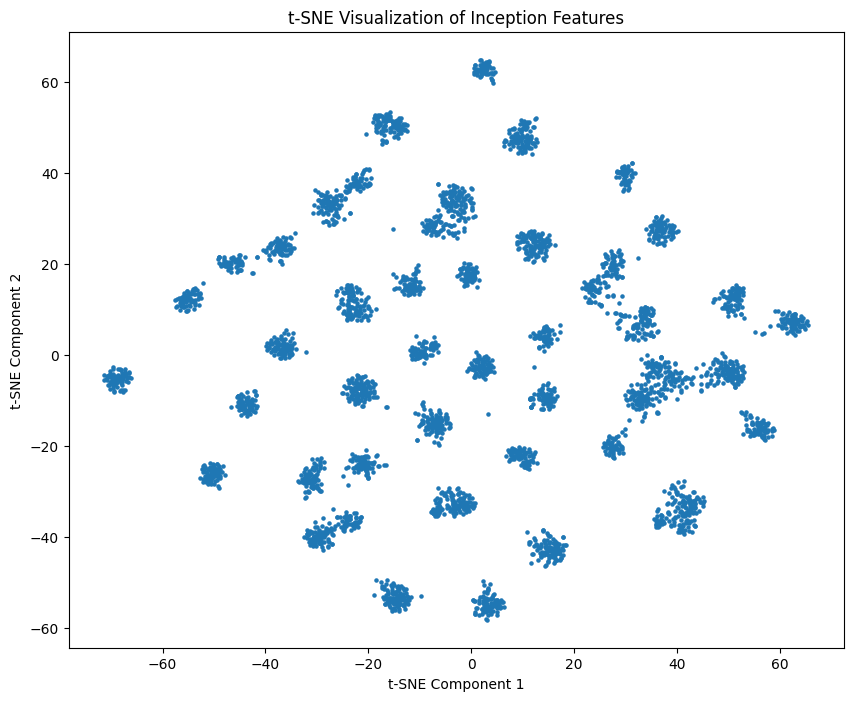

In [30]:
# 对特征向量进行 t-SNE 降维
tsne = TSNE(n_components=2, random_state=42)
inception_features_tsne = tsne.fit_transform(inception_features)

# 可视化 t-SNE 结果
plt.figure(figsize=(10, 8))
plt.scatter(inception_features_tsne[:, 0], inception_features_tsne[:, 1], s=5)
plt.title('t-SNE Visualization of Inception Features')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.show()

# 模型

## DNN

In [31]:
#准备callback
EarlyStop_callback = keras.callbacks.EarlyStopping(monitor='val_loss',patience=10, restore_best_weights=True)
my_callback=[EarlyStop_callback]

In [32]:
#DNN模型
dnn = keras.models.Sequential([
    InputLayer(inception_features.shape[1:]),
    Dropout(0.7),
    Dense(n_classes, activation='softmax')
])

dnn.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#训练模型
h = dnn.fit(inception_features, y,
            batch_size=128,
            epochs=30,
            validation_split=0.1,
            callbacks=my_callback)

Epoch 1/30
30/30 [==============================] - 1s 23ms/step - loss: 2.8160 - accuracy: 0.3752 - val_loss: 1.3674 - val_accuracy: 0.9058
Epoch 2/30
30/30 [==============================] - 0s 10ms/step - loss: 1.0210 - accuracy: 0.8596 - val_loss: 0.5419 - val_accuracy: 0.9372
Epoch 3/30
30/30 [==============================] - 0s 11ms/step - loss: 0.5302 - accuracy: 0.9123 - val_loss: 0.3459 - val_accuracy: 0.9469
Epoch 4/30
30/30 [==============================] - 0s 11ms/step - loss: 0.3601 - accuracy: 0.9306 - val_loss: 0.2821 - val_accuracy: 0.9396
Epoch 5/30
30/30 [==============================] - 0s 11ms/step - loss: 0.2885 - accuracy: 0.9381 - val_loss: 0.2447 - val_accuracy: 0.9444
Epoch 6/30
30/30 [==============================] - 0s 10ms/step - loss: 0.2465 - accuracy: 0.9441 - val_loss: 0.2213 - val_accuracy: 0.9493
Epoch 7/30
30/30 [==============================] - 0s 11ms/step - loss: 0.2262 - accuracy: 0.9473 - val_loss: 0.2094 - val_accuracy: 0.9420
Epoch 8/30
30

In [33]:
dnn.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dropout (Dropout)           (None, 2048)              0         
                                                                 
 dense (Dense)               (None, 48)                98352     
                                                                 
Total params: 98352 (384.19 KB)
Trainable params: 98352 (384.19 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [34]:
#评估模型
dnn.evaluate(inception_features,y,verbose=2)

130/130 - 0s - loss: 0.0586 - accuracy: 0.9843 - 265ms/epoch - 2ms/step


[0.05857013911008835, 0.9842691421508789]

{'loss': [2.8159871101379395, 1.0210026502609253, 0.5301859974861145, 0.36011481285095215, 0.2885112166404724, 0.24645432829856873, 0.22619955241680145, 0.1990804225206375, 0.1894218623638153, 0.1694962978363037, 0.16154401004314423, 0.15829028189182281, 0.1466142237186432, 0.13726505637168884, 0.1403365582227707, 0.12619803845882416, 0.12167215347290039, 0.11574041098356247, 0.11778225004673004, 0.10425141453742981, 0.10278603434562683, 0.1011277362704277, 0.10067284107208252, 0.09540621936321259, 0.0909975916147232, 0.08157929033041, 0.09078396111726761, 0.089835986495018, 0.08317344635725021, 0.08160370588302612], 'accuracy': [0.3752017319202423, 0.8596019148826599, 0.9123184680938721, 0.9306078553199768, 0.9381387829780579, 0.9440559148788452, 0.9472835063934326, 0.9537385702133179, 0.9478214383125305, 0.9566971659660339, 0.9548144340515137, 0.9558902382850647, 0.9618074297904968, 0.9604626297950745, 0.9596557021141052, 0.9626142978668213, 0.9671866297721863, 0.9679935574531555, 0.

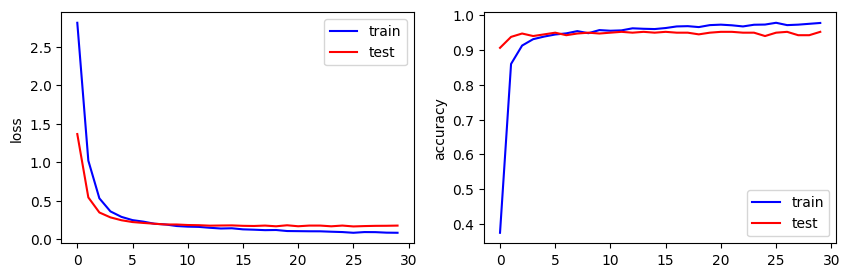

In [35]:
#可视化结果
print(h.history)
loss = h.history['loss']
acc = h.history['accuracy']
val_loss = h.history['val_loss']
val_acc = h.history['val_accuracy']

plt.figure(figsize=(10,3))

#绘制损失图
plt.subplot(121)
plt.plot(loss,color='b',label='train')
plt.plot(val_loss,color='r',label='test')
plt.ylabel('loss')
plt.legend()

#绘制准确率图
plt.subplot(122)
plt.plot(acc,color='b',label='train')
plt.plot(val_acc,color='r',label='test')
plt.ylabel('accuracy')
plt.legend()

# 特征提取（融合特征）

In [37]:
#使用Xception作为提取器提取特征。
xception_preprocessor = preprocess_input
xception_features = get_features(Xception,xception_preprocessor,img_size, X)

65/65 [==============================] - 928s 14s/step
Feature maps shape:  (4132, 2048)


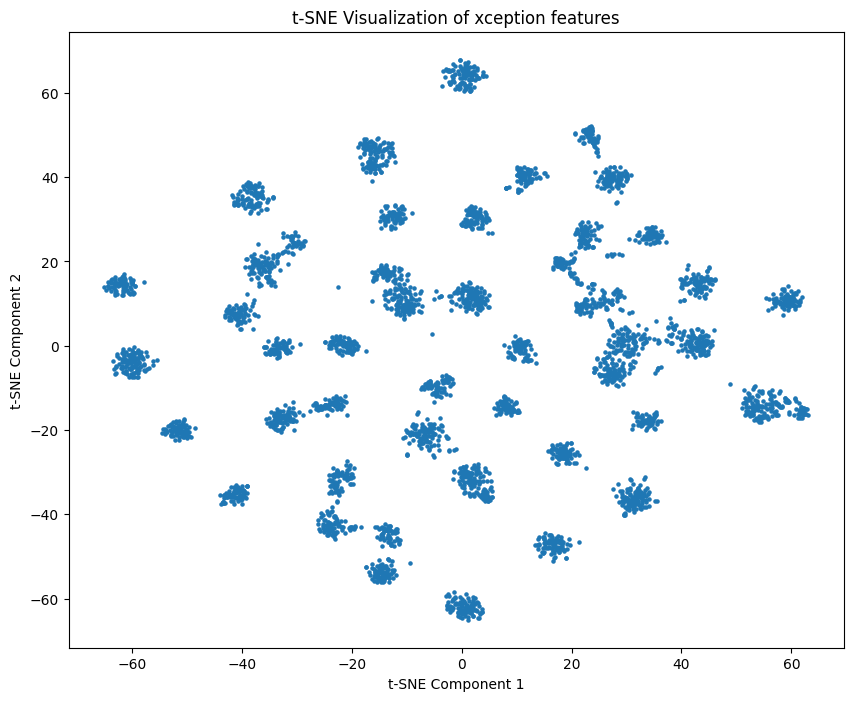

In [38]:
# 对特征向量进行 t-SNE 降维
tsne = TSNE(n_components=2, random_state=42)
xception_features_tsne = tsne.fit_transform(xception_features)

# 可视化 t-SNE 结果
plt.figure(figsize=(10, 8))
plt.scatter(xception_features_tsne[:, 0], xception_features_tsne[:, 1], s=5)
plt.title('t-SNE Visualization of xception features')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.show()

In [39]:
#使用NASNetLarge作为提取器提取特征。
nasnet_preprocessor = preprocess_input
nasnet_features = get_features(NASNetLarge,
                               nasnet_preprocessor,
                               img_size, X)

65/65 [==============================] - 2447s 38s/step
Feature maps shape:  (4132, 4032)


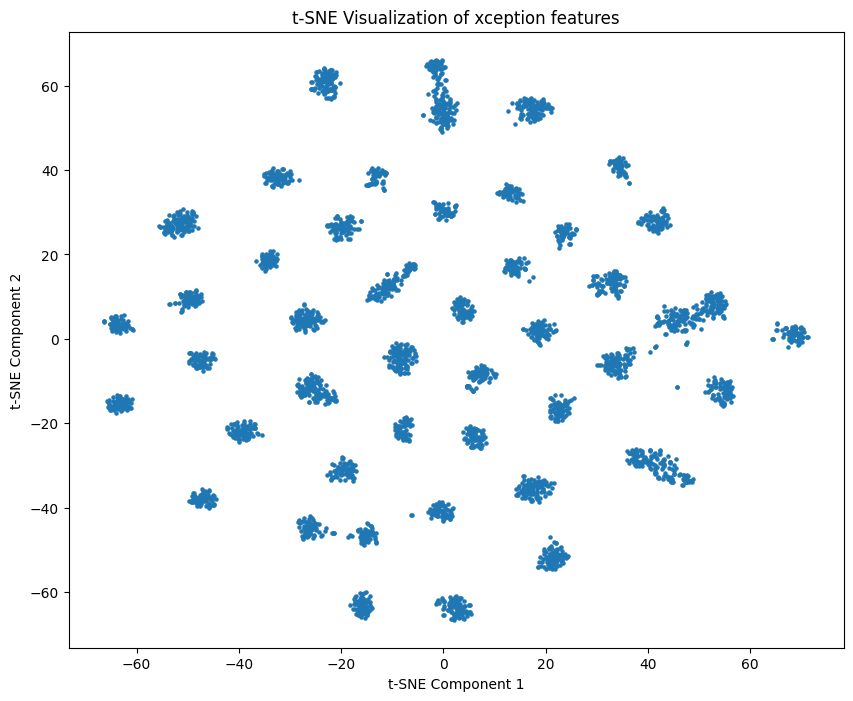

In [42]:
# 对特征向量进行 t-SNE 降维
tsne = TSNE(n_components=2, random_state=42)
nasnet_features_tsne = tsne.fit_transform(nasnet_features)

# 可视化 t-SNE 结果
plt.figure(figsize=(10, 8))
plt.scatter(nasnet_features_tsne[:, 0], nasnet_features_tsne[:, 1], s=5)
plt.title('t-SNE Visualization of xception features')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.show()

In [43]:
#使用InceptionResNetV2作为提取器提取特征。
inc_resnet_preprocessor = preprocess_input
inc_resnet_features = get_features(InceptionResNetV2,
                                   inc_resnet_preprocessor,
                                   img_size, X)

65/65 [==============================] - 1206s 18s/step
Feature maps shape:  (4132, 1536)


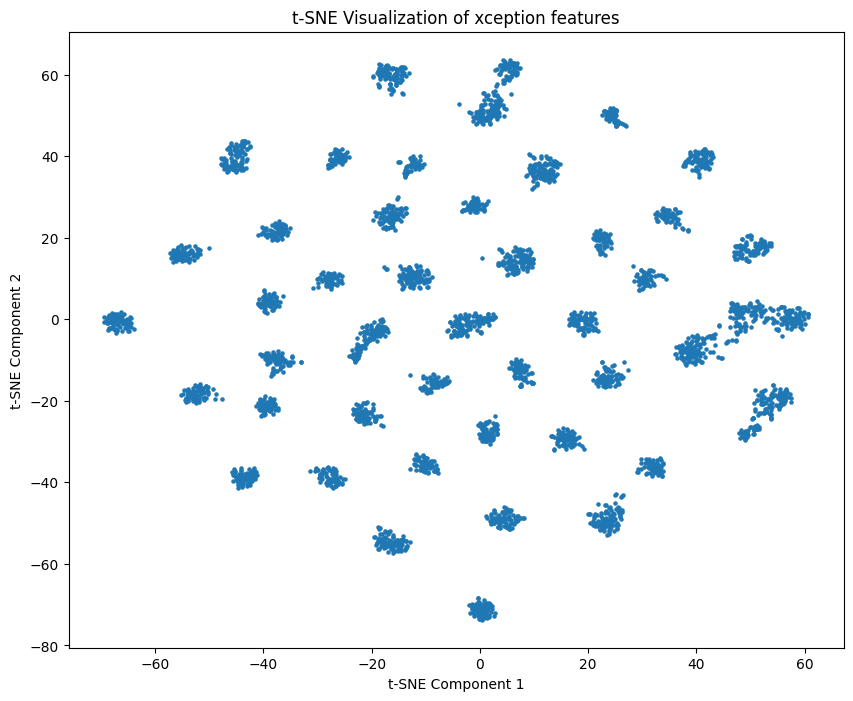

In [44]:
# 对特征向量进行 t-SNE 降维
tsne = TSNE(n_components=2, random_state=42)
inc_resnet_features_tsne = tsne.fit_transform(inc_resnet_features)

# 可视化 t-SNE 结果
plt.figure(figsize=(10, 8))
plt.scatter(inc_resnet_features_tsne[:, 0], inc_resnet_features_tsne[:, 1], s=5)
plt.title('t-SNE Visualization of xception features')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.show()

In [25]:
#删除无用变量释放空间
del X

In [45]:
final_features = np.concatenate([inception_features,
                                 xception_features,
                                 nasnet_features,
                                 inc_resnet_features,], axis=-1)
print('Final feature maps shape', final_features.shape)

Final feature maps shape (4132, 9664)


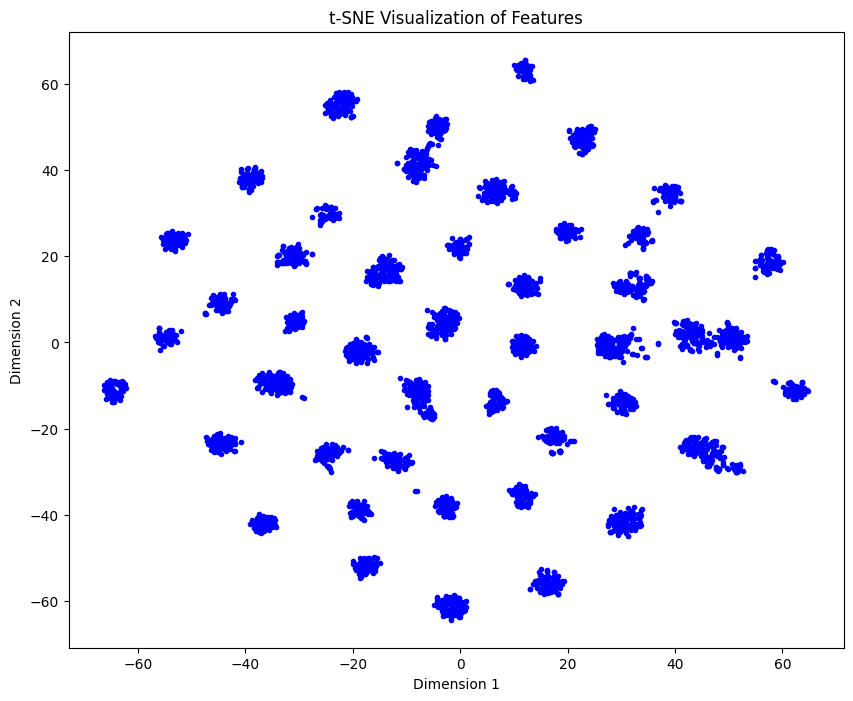

In [46]:
# 使用 t-SNE 进行降维
tsne = TSNE(n_components=2, random_state=42)
features_tsne = tsne.fit_transform(final_features)

# 可视化降维后的特征
plt.figure(figsize=(10, 8))
plt.scatter(features_tsne[:, 0], features_tsne[:, 1], marker='.', color='b')
plt.title('t-SNE Visualization of Features')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.show()

# 模型

## DNN

In [47]:
#Prepare call backs
EarlyStop_callback = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
my_callback=[EarlyStop_callback]

In [48]:
#DNN模型
dnn = keras.models.Sequential([
    InputLayer(final_features.shape[1:]),
    Dropout(0.7),
    Dense(n_classes, activation='softmax')
])

dnn.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#训练模型
b = dnn.fit(final_features, y,
            batch_size=128,
            epochs=30,
            validation_split=0.1,
            callbacks=my_callback)

Epoch 1/30
30/30 [==============================] - 1s 31ms/step - loss: 0.9622 - accuracy: 0.8066 - val_loss: 0.1410 - val_accuracy: 0.9565
Epoch 2/30
30/30 [==============================] - 1s 24ms/step - loss: 0.0980 - accuracy: 0.9688 - val_loss: 0.1245 - val_accuracy: 0.9565
Epoch 3/30
30/30 [==============================] - 1s 26ms/step - loss: 0.0823 - accuracy: 0.9739 - val_loss: 0.1211 - val_accuracy: 0.9614
Epoch 4/30
30/30 [==============================] - 1s 26ms/step - loss: 0.0684 - accuracy: 0.9771 - val_loss: 0.1273 - val_accuracy: 0.9565
Epoch 5/30
30/30 [==============================] - 1s 25ms/step - loss: 0.0587 - accuracy: 0.9812 - val_loss: 0.1113 - val_accuracy: 0.9638
Epoch 6/30
30/30 [==============================] - 1s 26ms/step - loss: 0.0498 - accuracy: 0.9831 - val_loss: 0.1171 - val_accuracy: 0.9614
Epoch 7/30
30/30 [==============================] - 1s 26ms/step - loss: 0.0463 - accuracy: 0.9847 - val_loss: 0.1169 - val_accuracy: 0.9638
Epoch 8/30
30

In [49]:
#评估模型
dnn.evaluate(final_features,y,verbose=2)

130/130 - 0s - loss: 0.0294 - accuracy: 0.9913 - 268ms/epoch - 2ms/step


[0.029392888769507408, 0.9912875294685364]

{'loss': [0.9621874094009399, 0.09804616868495941, 0.08227062225341797, 0.06835604459047318, 0.05872989445924759, 0.04983694478869438, 0.04629279300570488, 0.04409651830792427, 0.03578602895140648, 0.03051355667412281, 0.029411975294351578, 0.025269875302910805, 0.02247440069913864, 0.020100602880120277, 0.021846847608685493, 0.017726393416523933, 0.02090183086693287, 0.01706797070801258, 0.014421547763049603, 0.014185243286192417], 'accuracy': [0.806616485118866, 0.96880042552948, 0.9739106893539429, 0.9771382212638855, 0.9811726808547974, 0.9830554127693176, 0.9846691489219666, 0.9846691489219666, 0.9905863404273987, 0.9913932085037231, 0.9908552765846252, 0.9938138723373413, 0.995427668094635, 0.995427668094635, 0.9935449361801147, 0.995427668094635, 0.9940828680992126, 0.9948897361755371, 0.9978483319282532, 0.9967724680900574], 'val_loss': [0.1410171538591385, 0.12451353669166565, 0.12109682708978653, 0.1273145079612732, 0.1112685576081276, 0.11705969274044037, 0.11685208976268768

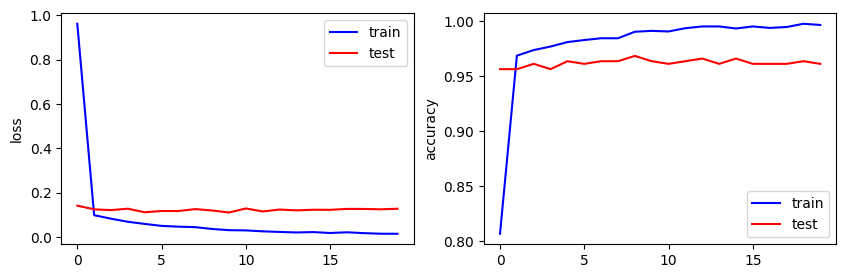

In [50]:
#可视化结果
print(b.history)
loss = b.history['loss']
acc = b.history['accuracy']
val_loss = b.history['val_loss']
val_acc = b.history['val_accuracy']

plt.figure(figsize=(10,3))

#绘制损失图
plt.subplot(121)
plt.plot(loss,color='b',label='train')
plt.plot(val_loss,color='r',label='test')
plt.ylabel('loss')
plt.legend()

#绘制准确率图
plt.subplot(122)
plt.plot(acc,color='b',label='train')
plt.plot(val_acc,color='r',label='test')
plt.ylabel('accuracy')
plt.legend()

# 测试集

In [51]:
sample_df = pd.read_csv('sample-long.csv')

In [52]:
#类似操作用于测试集
def images_to_array2(data_dir, labels_dataframe, img_size = (224,224,3)):
    images_names = labels_dataframe['id']
    data_size = len(images_names)
    X = np.zeros([data_size, img_size[0], img_size[1], 3], dtype=np.uint8)
    
    for i in tqdm(range(data_size)):
        image_name = images_names[i]
        img_dir = os.path.join(data_dir, image_name+'.jpg')
        img_pixels = tf.keras.preprocessing.image.load_img(img_dir, target_size=img_size)
        X[i] = img_pixels
        
    print('Ouptut Data Size: ', X.shape)
    return X

test_data = images_to_array2(test_dir, sample_df, img_size)

100%|█████████████████████████████████████████████████████████████████████████████| 4132/4132 [00:10<00:00, 382.87it/s]

Ouptut Data Size:  (4132, 331, 331, 3)


In [53]:
#提取测试集特征
inception_features = get_features(InceptionV3, inception_preprocessor, img_size, test_data)
xception_features = get_features(Xception, xception_preprocessor, img_size, test_data)
nasnet_features = get_features(NASNetLarge, nasnet_preprocessor, img_size, test_data)
inc_resnet_features = get_features(InceptionResNetV2, inc_resnet_preprocessor, img_size, test_data)
#融合特征得到最终特征
test_features = np.concatenate([inception_features,
                                 xception_features,
                                 nasnet_features,
                                 inc_resnet_features],axis=-1)
print('Final feature maps shape', test_features.shape)

65/65 [==============================] - 549s 8s/step
Feature maps shape:  (4132, 2048)
65/65 [==============================] - 895s 14s/step
Feature maps shape:  (4132, 2048)
65/65 [==============================] - 2525s 39s/step
Feature maps shape:  (4132, 4032)
65/65 [==============================] - 1413s 22s/step
Feature maps shape:  (4132, 1536)
Final feature maps shape (4132, 9664)


In [77]:
del test_data 

In [54]:
#在给定测试数据特征的情况下预测标签。
y_pred = dnn.predict(test_features, batch_size=128)

33/33 [==============================] - 0s 4ms/step


In [55]:
for b in dog_breeds:
    sample_df[b] = y_pred[:,class_to_num[b]]
sample_df.to_csv('pred-long.csv', index=None)